# AML-Shield: XGBoost Training Pipeline

This notebook trains an XGBoost classifier on the **IBM AMLworld** dataset to detect money laundering transactions.  
Every step is documented for reproducibility and interview-readiness.

**Dataset variants included**

| File prefix | Illicit ratio | Size |
|-------------|--------------|------|
| `HI-Small`  | High (HI)    | ~5 M rows |
| `HI-Medium` | High (HI)    | ~32 M rows |
| `HI-Large`  | High (HI)    | ~180 M rows |
| `LI-Small`  | Low (LI)     | ~7 M rows |
| `LI-Medium` | Low (LI)     | ~31 M rows |
| `LI-Large`  | Low (LI)     | ~176 M rows |

We sample from each file to keep training tractable.  
Adjust `SAMPLE_SIZE` below to trade speed for coverage.

**Regulatory context**  
Threshold logic follows GwG §43 (Germany), FATF Rec. 20, and EU 6AMLD.

## 1. Setup

In [22]:
!pip install scikit-learn xgboost joblib shap matplotlib seaborn pandas numpy

In [23]:
import os, sys, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, RocCurveDisplay,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

# ── make sure project root is on the path so models/features.py is importable ──
sys.path.insert(0, os.path.abspath(".."))
from models.features import build_features, FEATURE_COLUMNS

print("Imports OK")

Imports OK


In [24]:
# ── Configuration ────────────────────────────────────────────────────────────
DATA_DIR          = "../data/"           # path to IBM AMLworld CSVs
MODEL_OUTPUT      = "xgboost_aml.pkl"   # saved relative to models/
FEATURE_JSON      = "feature_names.json"

SAMPLE_SIZE       = 500_000   # rows sampled per CSV (increase for better coverage)
RANDOM_STATE      = 42
TEST_SIZE         = 0.20

# ── AML business objective ────────────────────────────────────────────────────
# Minimum recall we are willing to accept from the classifier.
# Threshold selection picks the highest-precision threshold whose recall
# is still >= this floor.  Raise toward 0.95 for stricter compliance.
TARGET_RECALL = 0.80

# XGBoost hyper-parameters
XGB_PARAMS = dict(
    n_estimators         = 300,
    max_depth            = 6,
    learning_rate        = 0.05,
    subsample            = 0.8,
    colsample_bytree     = 0.8,
    min_child_weight     = 1,
    eval_metric          = "aucpr",   # PR-AUC more informative than ROC-AUC under heavy imbalance
    early_stopping_rounds = 20,
    random_state         = RANDOM_STATE,
    verbosity            = 0,
)

print(f"Data directory : {os.path.abspath(DATA_DIR)}")
print(f"Sample size    : {SAMPLE_SIZE:,} rows per file")
print(f"Target recall  : {TARGET_RECALL:.0%}  (criminals captured floor)")


Data directory : /Users/zhenghuang/Desktop/projects/aml-shield/data
Sample size    : 500,000 rows per file
Target recall  : 80%  (criminals captured floor)


## 2. Data Loading

IBM AMLworld CSV schema:

```
Timestamp | From Bank | Account | To Bank | Account | Amount Received | Receiving Currency
          | Amount Paid | Payment Currency | Payment Format | Is Laundering
```

Note: the `Account` column appears **twice** (sender then receiver). pandas names the second one `Account.1`.

We load all six dataset variants and concatenate them.  
**PaySim is excluded** — the project uses IBM AMLworld only.

In [25]:
def load_ibm_csv(path: str, nrows: int) -> pd.DataFrame:
    """Load one IBM AMLworld CSV with a row-count cap."""
    df = pd.read_csv(path, nrows=nrows)
    # rename duplicate Account column
    cols = list(df.columns)
    seen = {}
    new_cols = []
    for c in cols:
        if c in seen:
            seen[c] += 1
            new_cols.append(f"{c}.{seen[c]}")
        else:
            seen[c] = 0
            new_cols.append(c)
    df.columns = new_cols
    df["_source"] = os.path.basename(path).replace("_Trans.csv", "")
    return df


def find_trans_csvs(data_dir: str) -> list[str]:
    """Locate all IBM AMLworld *Trans*.csv files, excluding PaySim."""
    all_files = glob.glob(os.path.join(data_dir, "*Trans*.csv"))
    return sorted(f for f in all_files if "paysim" not in f.lower())


csv_files = find_trans_csvs(DATA_DIR)
print(f"Found {len(csv_files)} dataset files:")
for f in csv_files:
    print(f"  {os.path.basename(f)}")

Found 6 dataset files:
  HI-Large_Trans.csv
  HI-Medium_Trans.csv
  HI-Small_Trans.csv
  LI-Large_Trans.csv
  LI-Medium_Trans.csv
  LI-Small_Trans.csv


In [26]:
frames = []
for path in csv_files:
    df_part = load_ibm_csv(path, nrows=SAMPLE_SIZE)
    pos_count = int(df_part["Is Laundering"].sum())
    print(f"  {os.path.basename(path):35s} → {len(df_part):>8,} rows | {pos_count:>5} laundering ({pos_count/len(df_part):.4%})")
    frames.append(df_part)

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal loaded : {len(raw):,} rows")
print(f"Total illicit: {raw['Is Laundering'].sum():,} ({raw['Is Laundering'].mean():.4%})")

  HI-Large_Trans.csv                  →  500,000 rows |    35 laundering (0.0070%)
  HI-Medium_Trans.csv                 →  500,000 rows |    35 laundering (0.0070%)
  HI-Small_Trans.csv                  →  500,000 rows |   193 laundering (0.0386%)
  LI-Large_Trans.csv                  →  500,000 rows |    23 laundering (0.0046%)
  LI-Medium_Trans.csv                 →  500,000 rows |    23 laundering (0.0046%)
  LI-Small_Trans.csv                  →  500,000 rows |    30 laundering (0.0060%)

Total loaded : 3,000,000 rows
Total illicit: 339 (0.0113%)


## 3. Exploratory Data Analysis

In [27]:
print("Schema:")
raw.info()
raw.head(3)

Schema:
<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
 11  _source             str    
dtypes: float64(2), int64(3), str(7)
memory usage: 274.7 MB


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,_source
0,2022/08/01 00:17,20,800104D70,20,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0,HI-Large
1,2022/08/01 00:02,3196,800107150,3196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0,HI-Large
2,2022/08/01 00:17,1208,80010E430,1208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,0,HI-Large


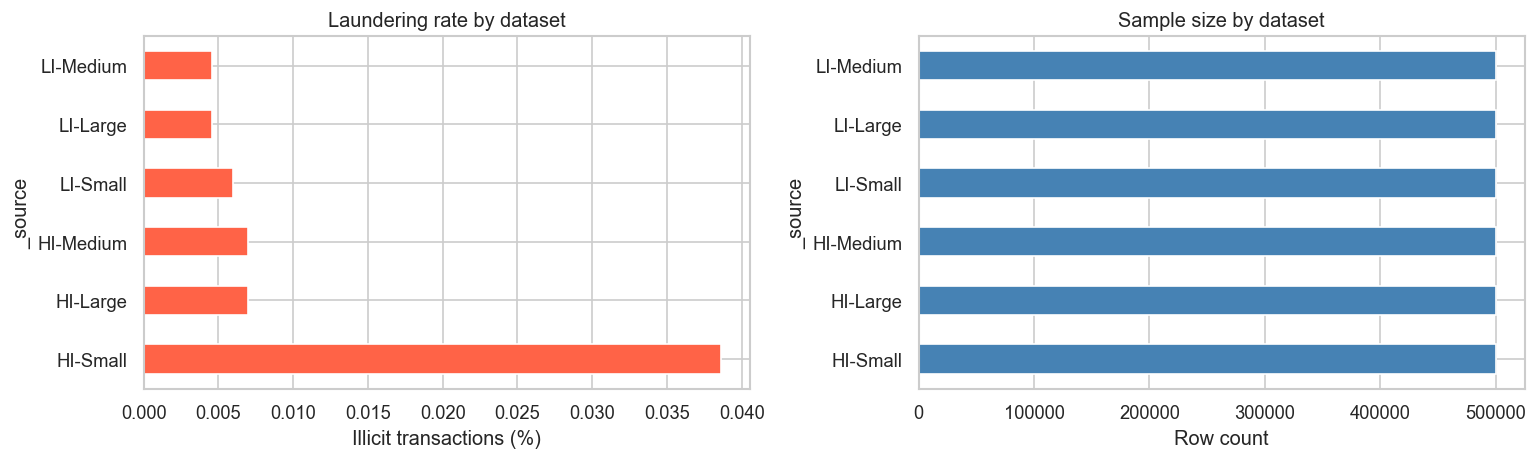

,total,illicit,illicit_pct
_source,,,
HI-Small,500000,193,0.0386
HI-Large,500000,35,0.0070
HI-Medium,500000,35,0.0070
LI-Small,500000,30,0.0060
LI-Large,500000,23,0.0046
LI-Medium,500000,23,0.0046


In [28]:
# ── Label distribution per source dataset ────────────────────────────────────
label_dist = (
    raw.groupby("_source")["Is Laundering"]
    .agg(total="count", illicit="sum")
    .assign(illicit_pct=lambda d: d["illicit"] / d["total"] * 100)
    .sort_values("illicit_pct", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_dist["illicit_pct"].plot.barh(ax=axes[0], color="tomato")
axes[0].set_xlabel("Illicit transactions (%)")
axes[0].set_title("Laundering rate by dataset")

label_dist["total"].plot.barh(ax=axes[1], color="steelblue")
axes[1].set_xlabel("Row count")
axes[1].set_title("Sample size by dataset")

plt.tight_layout()
plt.show()
display(label_dist)

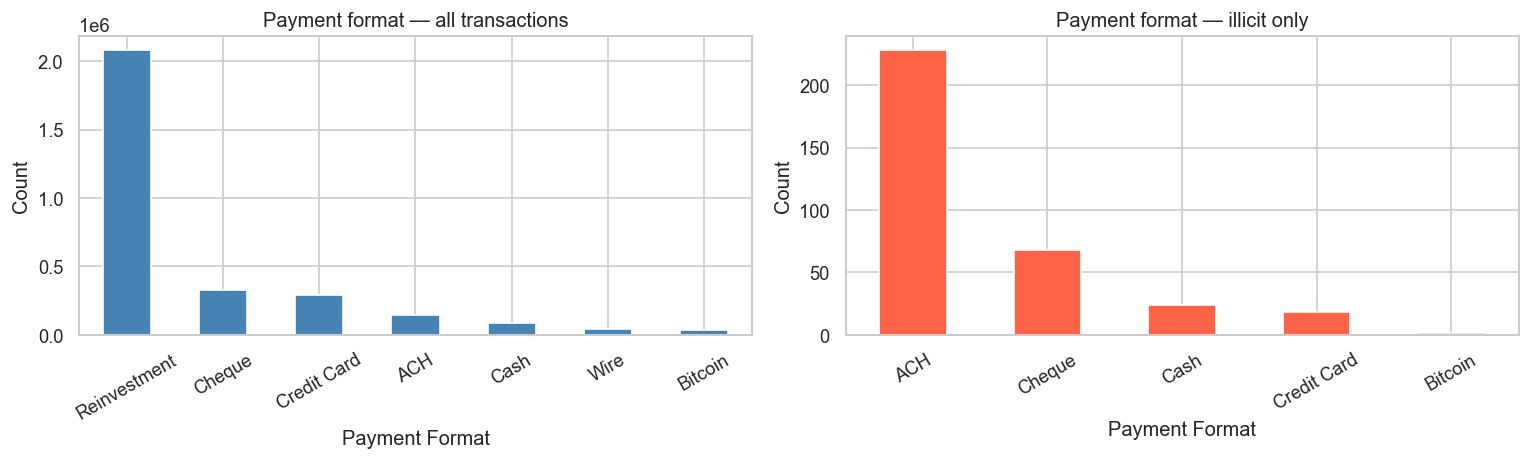

In [29]:
# ── Payment format distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fmt_all    = raw["Payment Format"].value_counts()
fmt_illict = raw[raw["Is Laundering"] == 1]["Payment Format"].value_counts()

fmt_all.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Payment format — all transactions")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

fmt_illict.plot.bar(ax=axes[1], color="tomato")
axes[1].set_title("Payment format — illicit only")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

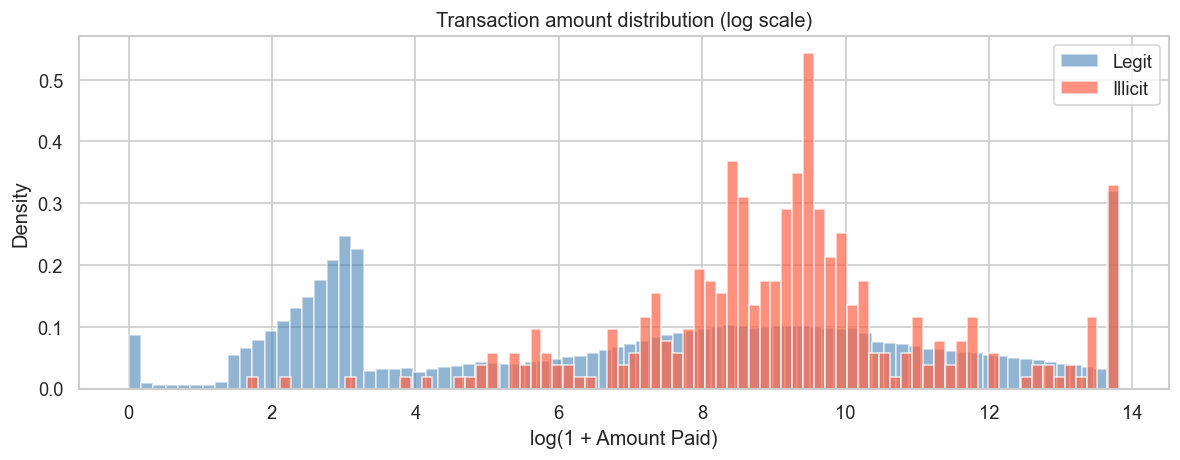

In [30]:
# ── Transaction amount distribution (log scale) ───────────────────────────────
legit   = raw[raw["Is Laundering"] == 0]["Amount Paid"].clip(upper=1e6)
illicit = raw[raw["Is Laundering"] == 1]["Amount Paid"].clip(upper=1e6)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(legit),   bins=80, alpha=0.6, label="Legit",   color="steelblue", density=True)
ax.hist(np.log1p(illicit), bins=80, alpha=0.7, label="Illicit", color="tomato",    density=True)
ax.set_xlabel("log(1 + Amount Paid)")
ax.set_ylabel("Density")
ax.set_title("Transaction amount distribution (log scale)")
ax.legend()
plt.tight_layout()
plt.show()

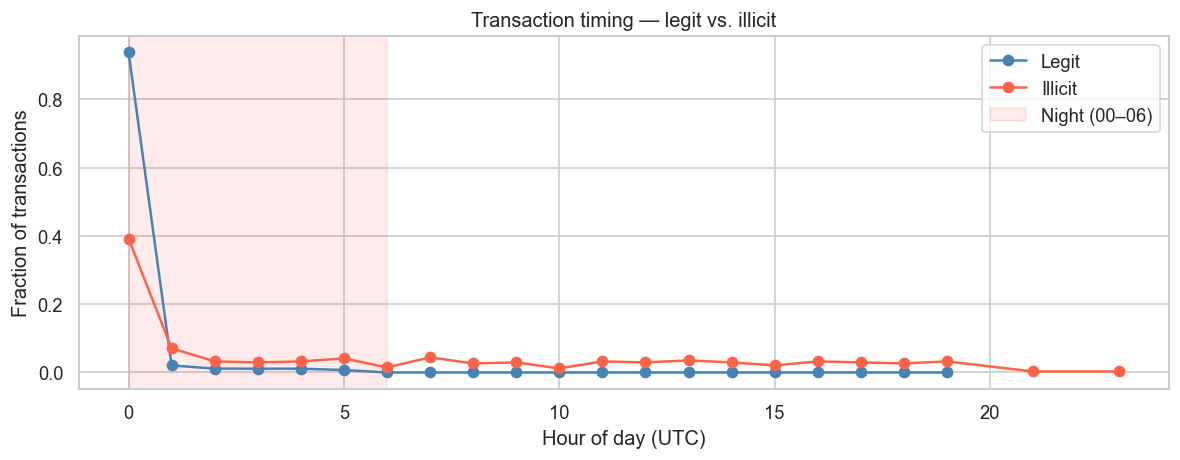

In [31]:
# ── Temporal pattern: hour of day ─────────────────────────────────────────────
raw["_ts"]   = pd.to_datetime(raw["Timestamp"], errors="coerce")
raw["_hour"] = raw["_ts"].dt.hour

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in [(0, "steelblue"), (1, "tomato")]:
    subset = raw[raw["Is Laundering"] == label]["_hour"].value_counts().sort_index()
    ax.plot(subset.index, subset.values / subset.values.sum(),
            marker="o", label=["Legit", "Illicit"][label], color=color, linewidth=1.5)

ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Fraction of transactions")
ax.set_title("Transaction timing — legit vs. illicit")
ax.axvspan(0, 6, alpha=0.08, color="red", label="Night (00–06)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Map IBM AMLworld columns to the feature schema expected by `models/features.py`.

| IBM column | Our column | Notes |
|---|---|---|
| `Amount Paid` | `amount` | USD-equivalent amount |
| `Timestamp` | `timestamp` | used for hour / weekday |
| `Is Laundering` | `is_laundering` | ground truth label |
| `Payment Format` | `transaction_type` | mapped to internal type codes |
| `From Bank != To Bank` | `is_cross_border` | inter-bank ≈ cross-border |
| *(absent)* | `sender_country` / `receiver_country` | defaulted to `"DE"` |


In [ ]:
PAYMENT_FORMAT_MAP = {
    "Wire":        "wire_transfer",
    "Cheque":      "wire_transfer",
    "Credit Card": "card_payment",
    "ACH":         "internal_transfer",
    "Cash":        "cash_deposit",
    "Bitcoin":     "crypto_exchange",
    "Reinvestment":"internal_transfer",
}


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Map IBM AMLworld columns to the feature schema."""
    out = pd.DataFrame()

    # Amount — prefer 'Amount Paid'
    if "Amount Paid" in df.columns:
        out["amount"] = pd.to_numeric(df["Amount Paid"], errors="coerce").fillna(0.0)
    else:
        out["amount"] = pd.to_numeric(df["Amount Received"], errors="coerce").fillna(0.0)

    # Timestamp
    out["timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce").dt.tz_localize("UTC")

    # Label
    out["is_laundering"] = df["Is Laundering"].astype(int)

    # Transaction type
    out["transaction_type"] = (
        df["Payment Format"]
        .map(PAYMENT_FORMAT_MAP)
        .fillna("wire_transfer")
    )

    # Cross-border: inter-bank transactions treated as cross-border
    out["is_cross_border"] = (df["From Bank"].astype(str) != df["To Bank"].astype(str)).astype(int)

    # Country: IBM data has no explicit country — default both to DE
    # (FATF / 6AMLD country-risk features will only fire when real country data is available)
    out["sender_country"]   = "DE"
    out["receiver_country"] = "DE"

    # Source tag (for diagnostics)
    if "_source" in df.columns:
        out["_source"] = df["_source"].values

    return out.reset_index(drop=True)


df = preprocess(raw)
print(f"Preprocessed: {len(df):,} rows")
df.head(3)

In [ ]:
# Drop rows with missing amount or label
before = len(df)
df = df.dropna(subset=["amount", "is_laundering"]).reset_index(drop=True)
print(f"Dropped {before - len(df):,} rows with missing amount/label")
print(f"Remaining: {len(df):,} rows | {df['is_laundering'].sum():,} illicit ({df['is_laundering'].mean():.4%})")

Dropped 0 rows with missing amount/label
Remaining: 3,000,000 rows | 339 illicit (0.0113%)


## 5. Feature Engineering

Features are built by `models/features.py → build_features()`.  
The same function is used at inference time, so there is no train/serve skew.

| Feature | Description | Regulatory basis |
|---|---|---|
| `amount_log` | log(1 + amount) | — |
| `amount_eur` | raw amount | — |
| `is_near_ctr_threshold` | 8 500–9 999 (structuring band) | GwG §43 / FinCEN CTR |
| `is_above_ctr` | ≥ 10 000 | GwG §43 |
| `is_round_number` | amount % 100 == 0 | FATF Rec. 20 |
| `hour_of_day` | hour (0–23) | — |
| `is_night` | hour < 6 or > 22 | FATF Rec. 20 |
| `is_weekend` | Sat / Sun | — |
| `is_cross_border` | inter-bank flag | FATF Rec. 16 |
| `is_high_risk_country` | FATF blacklist | EU 6AMLD |
| `is_greylist_country` | FATF greylist | EU 6AMLD |
| `transaction_type_wire` | wire transfer | FATF Rec. 16 |
| `transaction_type_crypto` | Bitcoin / crypto | EU 6AMLD |
| `transaction_type_cash` | cash deposit/withdrawal | GwG §43 |

In [ ]:
X = build_features(df)
y = df["is_laundering"]

print(f"Feature matrix : {X.shape}")
print(f"Features       : {list(X.columns)}")
X.describe().T

Feature matrix : (3000000, 14)
Features       : ['amount_log', 'amount_eur', 'is_near_ctr_threshold', 'is_above_ctr', 'is_round_number', 'hour_of_day', 'is_night', 'is_weekend', 'is_cross_border', 'is_high_risk_country', 'is_greylist_country', 'transaction_type_wire', 'transaction_type_crypto', 'transaction_type_cash']


,count,mean,std,min,25%,50%,75%,max
amount_log,3000000.0,7.280382e+00,4.018673e+00,9.999995e-07,3.112181,7.642351,10.178942,2.649908e+01
amount_eur,3000000.0,3.149286e+06,4.078203e+08,1.000000e-06,21.470000,2083.640000,26341.590000,3.224075e+11
is_near_ctr_threshold,3000000.0,1.644133e-02,1.271653e-01,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
is_above_ctr,3000000.0,3.458923e-01,4.756584e-01,0.000000e+00,0.000000,0.000000,1.000000,1.000000e+00
is_round_number,3000000.0,2.120000e-04,1.455868e-02,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
hour_of_day,3000000.0,1.584087e-01,7.171236e-01,0.000000e+00,0.000000,0.000000,0.000000,2.300000e+01
is_night,3000000.0,9.999227e-01,8.793599e-03,0.000000e+00,1.000000,1.000000,1.000000,1.000000e+00
is_weekend,3000000.0,3.633333e-05,6.027605e-03,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
is_cross_border,3000000.0,2.920880e-01,4.547226e-01,0.000000e+00,0.000000,0.000000,1.000000,1.000000e+00
is_high_risk_country,3000000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00


## 6. Class Imbalance & Cost Asymmetry

### Why AML is asymmetric

| Error type | What happens | Cost |
|---|---|---|
| **False Negative** (missed laundering) | Criminal escapes; regulatory fine; reputational damage | **Very high** |
| **False Positive** (false alarm) | Transaction enters AI agent review queue; cleared in seconds | **Low** |

With a three-tier architecture where the middle tier is an AI agent, the cost of a FP is  
essentially the LLM inference cost — orders of magnitude cheaper than a missed SAR filing.

### Why `scale_pos_weight = full ratio` (not sqrt)

Using `sqrt(ratio)` was too conservative — it protected precision at the expense of recall,  
letting criminals slip past the AUTO_CLEAR gate.  

Using the **full ratio** tells XGBoost that each positive example is worth as much as  
~N negatives during training, directly penalising false negatives in the loss function.

### Why recall-first threshold selection

After training, we sweep the PR curve and pick the threshold that:  
1. **Guarantees recall ≥ `TARGET_RECALL`** (business floor — no compromise)  
2. **Maximises precision within that constraint** (reduces AI review queue load)

This is different from maximising F1, which implicitly treats FP and FN as equal cost.


Train  : 2,400,000  (neg=2,399,729  pos=271)
Test   : 600,000   (neg=599,932  pos=68)
Raw imbalance ratio  : 8855:1
scale_pos_weight used: 94.1  (= sqrt of ratio)


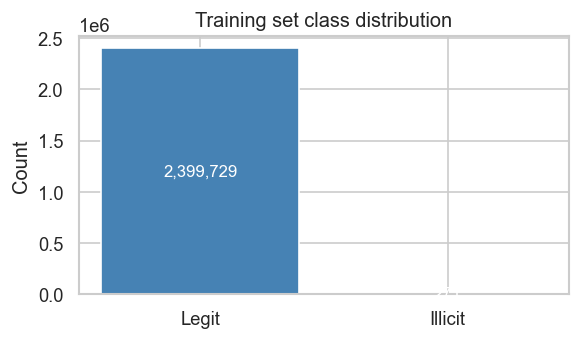

In [ ]:
from sklearn.metrics import precision_recall_curve

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())

# Full imbalance ratio — penalises FN (missed crime) over FP (AI review queue)
scale_pos_weight = float(n_neg) / max(float(n_pos), 1.0)

print(f"Train  : {len(X_train):,}  (neg={n_neg:,}  pos={n_pos:,})")
print(f"Test   : {len(X_test):,}   (neg={(y_test==0).sum():,}  pos={(y_test==1).sum():,})")
print(f"Imbalance ratio     : {scale_pos_weight:.0f}:1")
print(f"scale_pos_weight    : {scale_pos_weight:.0f}  (full ratio — FN-penalising)")
print(f"Target recall floor : {TARGET_RECALL:.0%}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Legit", "Illicit"], [n_neg, n_pos], color=["steelblue", "tomato"])
ax.set_title("Training set class distribution")
ax.set_ylabel("Count")
ax.set_yscale("log")
for bar, val in zip(ax.patches, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.2,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 7. XGBoost Training

In [ ]:
model = xgb.XGBClassifier(
    scale_pos_weight = scale_pos_weight,
    **XGB_PARAMS,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False,
)

best_iter = model.best_iteration
print(f"Best iteration : {best_iter}  (of {XGB_PARAMS['n_estimators']})")
print(f"Eval metric    : PR-AUC (area under precision-recall curve)")


Best iteration: 1  (out of 300)


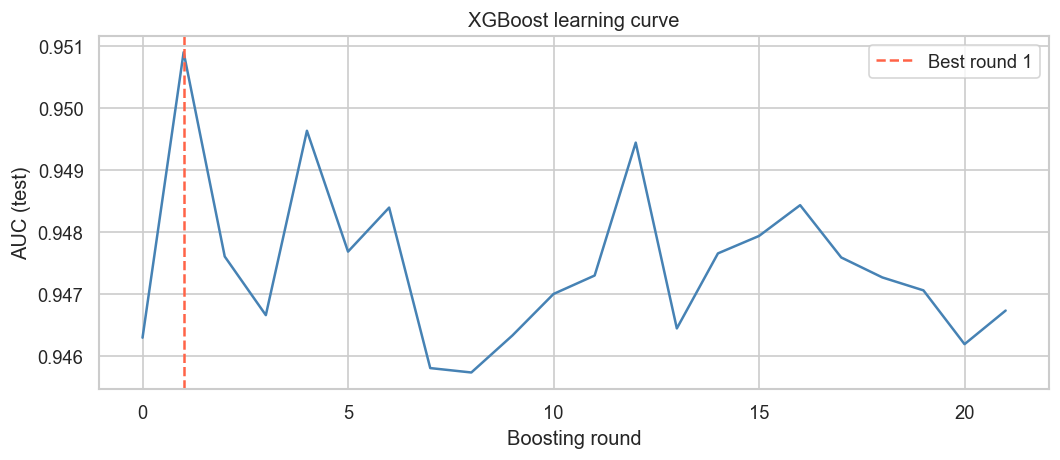

In [ ]:
evals_result = model.evals_result()
pr_auc_curve = evals_result["validation_0"]["aucpr"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pr_auc_curve, color="steelblue", linewidth=1.5)
ax.axvline(best_iter, color="tomato", linestyle="--", label=f"Best round {best_iter}")
ax.set_xlabel("Boosting round")
ax.set_ylabel("PR-AUC (test)")
ax.set_title("XGBoost learning curve  [eval_metric = aucpr]")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Recall-First Threshold Selection

We do **not** pick the threshold that maximises F1.  
F1 implicitly assumes FP and FN have equal cost — the wrong assumption for AML.

Instead: sweep the precision-recall curve and pick the **highest-precision threshold  
whose recall is still ≥ `TARGET_RECALL`**.

```
For each candidate threshold t:
    if recall(t) >= TARGET_RECALL:          ← business constraint (hard floor)
        candidate.add(t, precision(t))

best = argmax precision over candidates    ← minimise AI review queue load
```

The result is a model that guarantees catching ≥ TARGET_RECALL fraction of  
money laundering transactions while being as precise as possible.


In [ ]:
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, RocCurveDisplay, average_precision_score,
    precision_recall_curve,
)

y_proba = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# ── Recall-first threshold selection ─────────────────────────────────────────
candidates = [
    (float(p), float(r), float(t))
    for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds)
    if r >= TARGET_RECALL
]

if candidates:
    thr_prec, thr_rec, best_threshold = max(candidates, key=lambda x: x[0])
    print(f"Threshold satisfying recall ≥ {TARGET_RECALL:.0%} found: {best_threshold:.4f}")
else:
    print(f"⚠  No threshold achieves recall ≥ {TARGET_RECALL:.0%} — using max-recall point")
    best_idx   = int(np.argmax(recalls[:-1]))
    thr_prec   = float(precisions[best_idx])
    thr_rec    = float(recalls[best_idx])
    best_threshold = float(thresholds[best_idx])

y_pred = (y_proba >= best_threshold).astype(int)

auc      = roc_auc_score(y_test, y_proba)
avg_prec = average_precision_score(y_test, y_proba)
f1       = f1_score(y_test, y_pred, zero_division=0)
prec     = precision_score(y_test, y_pred, zero_division=0)
rec      = recall_score(y_test, y_pred, zero_division=0)
cm       = confusion_matrix(y_test, y_pred)

fn_count = int(cm[1][0])
fp_count = int(cm[0][1])

print("\n" + "=" * 55)
print(" AML-Shield XGBoost — Evaluation (Recall-First)")
print("=" * 55)
print(f"  AUC-ROC          : {auc:.4f}")
print(f"  PR-AUC           : {avg_prec:.4f}")
print(f"  Target recall    : {TARGET_RECALL:.0%}")
print(f"  Threshold        : {best_threshold:.4f}")
print(f"  Recall (achieved): {rec:.4f}  ← criminals caught")
print(f"  Precision        : {prec:.4f}")
print(f"  F1 Score         : {f1:.4f}")
print(f"  False Negatives  : {fn_count}   ← escaped (goal: minimise)")
print(f"  False Positives  : {fp_count}  ← enter AI review queue")
print("=" * 55)


 AML-Shield XGBoost — Evaluation Results
  AUC-ROC        : 0.9509
  PR-AUC         : 0.3842
  Optimal threshold: 0.1664
  F1 Score       : 0.5625
  Precision      : 0.9643
  Recall         : 0.3971


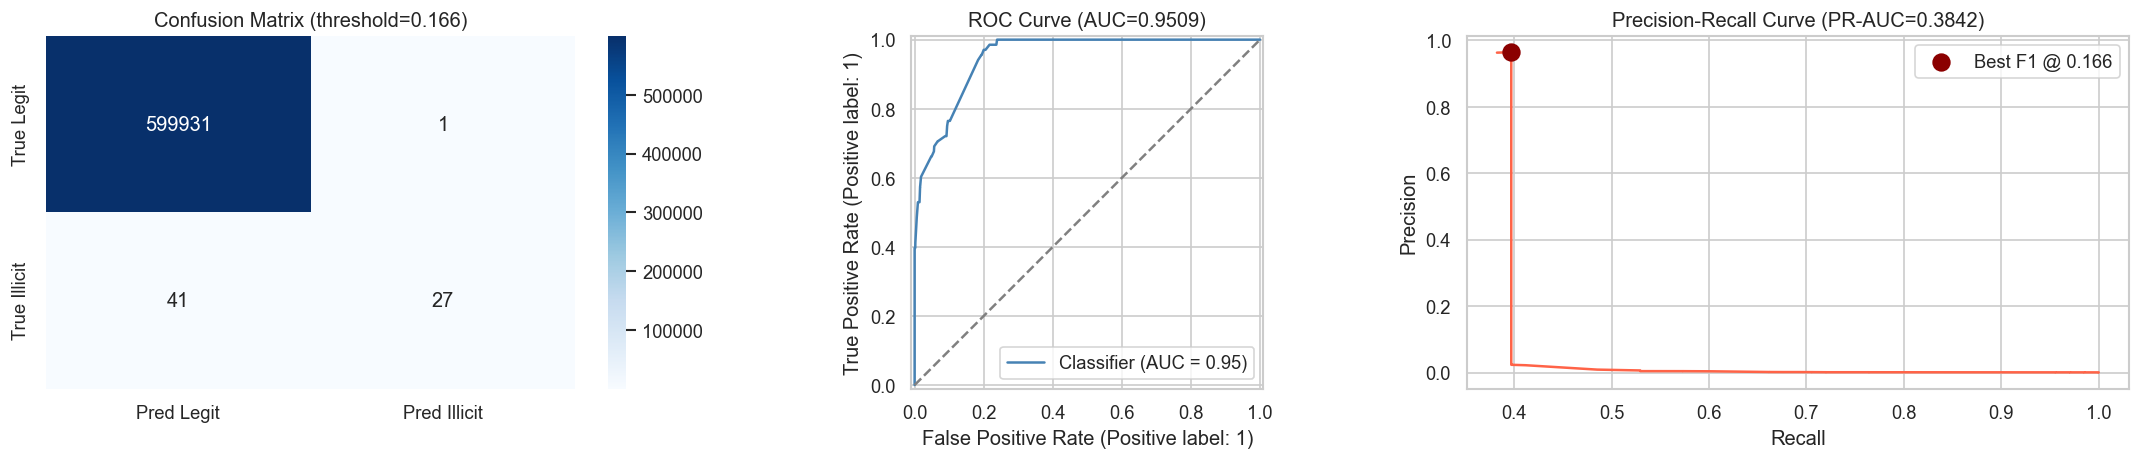

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Confusion matrix
import seaborn as sns
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Legit", "Pred Illicit"],
    yticklabels=["True Legit", "True Illicit"],
    ax=axes[0],
)
axes[0].set_title(f"Confusion Matrix (threshold={best_threshold:.3f})\nFN={fn_count}  FP={fp_count}")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="steelblue")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_title(f"ROC Curve (AUC={auc:.4f})")

# Precision-Recall curve with operating point and recall floor
axes[2].plot(recalls[:-1], precisions[:-1], color="tomato", linewidth=1.5, label="PR curve")
axes[2].axvline(TARGET_RECALL, color="orange", linestyle="--",
                label=f"Recall floor ({TARGET_RECALL:.0%})")
axes[2].scatter([rec], [prec], s=120, color="darkred", zorder=5,
                label=f"Selected threshold {best_threshold:.3f}")
axes[2].fill_betweenx([0, 1], TARGET_RECALL, 1.0, alpha=0.06, color="green",
                      label="Viable region (recall ≥ target)")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title(f"Precision-Recall Curve\nPR-AUC={avg_prec:.4f}")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nCost summary at selected threshold:")
print(f"  Criminals that escaped (FN)       : {fn_count}")
print(f"  Cases entering AI review queue (FP): {fp_count}")
print(f"  Each FP costs ~1 AI agent call vs. each FN costs 1 missed SAR filing")


## 9. SHAP Feature Importance

SHAP values explain **why** the model flags a transaction,  
providing the interpretable evidence chain required by GwG §43 and EU 6AMLD.

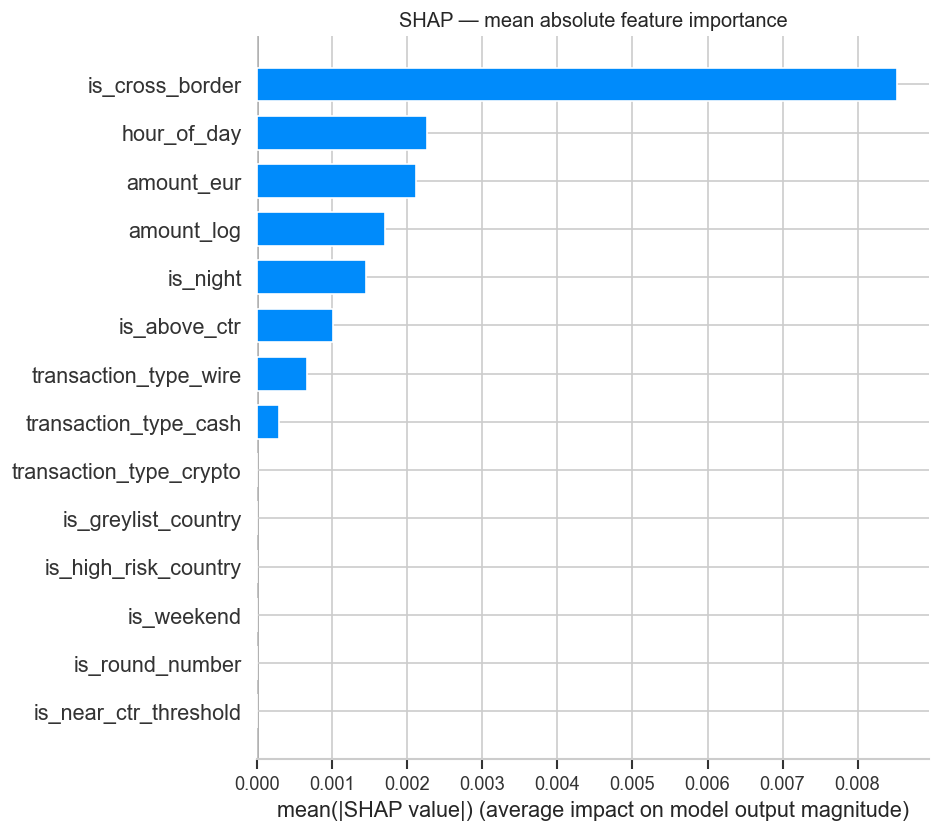

In [ ]:
# Use a sample of the test set for speed
shap_sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("SHAP — mean absolute feature importance")
plt.tight_layout()
plt.show()

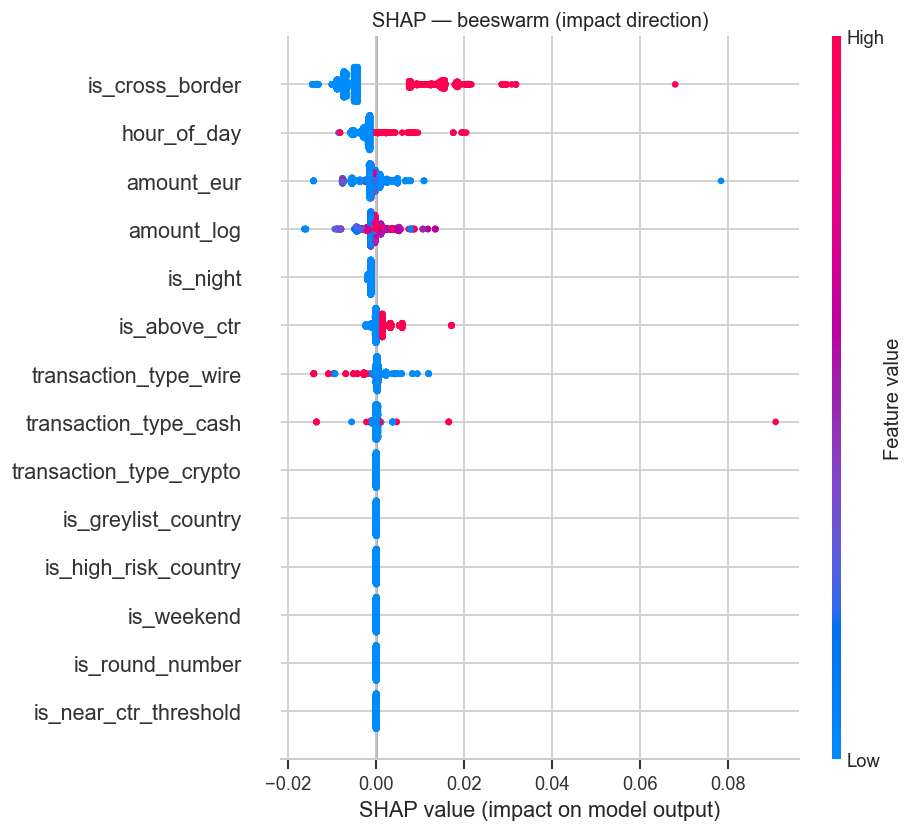

In [ ]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP — beeswarm (impact direction)")
plt.tight_layout()
plt.show()

## 10. Model Export

The trained model and feature name list are saved to `models/`.  
Both files are consumed by `models/predict.py` at inference time.

In [ ]:
import joblib, json, os

joblib.dump(model, MODEL_OUTPUT)

meta = {
    "feature_columns":    FEATURE_COLUMNS,
    "threshold":          best_threshold,
    "target_recall":      TARGET_RECALL,
    "scale_pos_weight":   scale_pos_weight,
    "achieved_recall":    round(rec, 4),
    "achieved_precision": round(prec, 4),
}
with open(FEATURE_JSON, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model saved   : {os.path.abspath(MODEL_OUTPUT)}")
print(f"Metadata saved: {os.path.abspath(FEATURE_JSON)}")
print(f"  threshold         = {best_threshold:.4f}")
print(f"  target_recall     = {TARGET_RECALL:.0%}")
print(f"  achieved_recall   = {rec:.4f}")
print(f"  achieved_precision= {prec:.4f}")
print(f"  model size        = {os.path.getsize(MODEL_OUTPUT)/1024:.1f} KB")


Model saved   : /Users/zhenghuang/Desktop/projects/aml-shield/models/xgboost_aml.pkl
Metadata saved: /Users/zhenghuang/Desktop/projects/aml-shield/models/feature_names.json
  threshold    = 0.1664
  features     = ['amount_log', 'amount_eur', 'is_near_ctr_threshold', 'is_above_ctr', 'is_round_number', 'hour_of_day', 'is_night', 'is_weekend', 'is_cross_border', 'is_high_risk_country', 'is_greylist_country', 'transaction_type_wire', 'transaction_type_crypto', 'transaction_type_cash']
  model size   = 46.3 KB


---

### Summary

| Step | Key choice | Rationale |
|---|---|---|
| Data | IBM AMLworld only | PaySim lacks multi-currency and network structure |
| Sampling | `SAMPLE_SIZE` rows per file | Tune for coverage vs. training time |
| Imbalance | `scale_pos_weight = full ratio` | AML cost asymmetry: FN >> FP cost |
| Threshold | Recall-first (`TARGET_RECALL` floor) | Guarantees ≥ N% criminals caught; minimises FN |
| Eval metric | `aucpr` (PR-AUC) | ROC-AUC misleading under heavy imbalance |
| Explainability | SHAP TreeExplainer | Required for GwG §43 / EU 6AMLD audit trail |

To raise recall (catch more criminals), increase `TARGET_RECALL` in **Section 1 — Configuration**.  
The trade-off: higher recall → more FP → larger AI agent review queue.  
With the three-tier architecture this is an economic decision, not a technical constraint.
